# 04: Direct, Indirect, and Total Effects for Discovery Quality

The previous notebook defined the mediation design. This notebook estimates the effects.

The causal story is built around three variables:

- `A_high_discovery`: whether an active user-day had high discovery breadth.
- `M_satisfaction_depth`: same-day satisfaction depth, built from watch-quality signals.
- `Y`: future user value, primarily future seven-day interactions.

The goal is to decompose the effect of high discovery exposure into:

- **Total effect**: the overall adjusted difference in future value between high-discovery and lower-discovery days.
- **Natural direct effect**: the part of the difference that remains if satisfaction depth is held at the lower-discovery counterfactual level.
- **Natural indirect effect**: the part of the difference that flows through the change in satisfaction depth.
- **Controlled direct effects**: treatment contrasts at fixed low, median, and high satisfaction levels.

This is still an observational analysis, so the estimates should be read as adjusted causal estimates under the assumptions documented in notebook 03. The notebook uses g-computation because it makes the counterfactual logic visible and easy to explain.

<!-- dataset-experiment-context -->
## Dataset and Mediation Design Context

This project uses KuaiRec interaction logs and metadata organized into active user-day records. The workflow constructs discovery-breadth, satisfaction-depth, quality-adjusted discovery, and shallow-click-pressure metrics from logged viewing behavior.

The data come from a real observational recommendation log. Discovery exposure, satisfaction depth, and future engagement arise from platform behavior, so the mediation analysis needs explicit identifying assumptions. The treatment is high discovery-breadth exposure, the mediator is same-day satisfaction depth, and the primary outcome is future seven-day interactions.

The project asks whether discovery exposure relates to future value directly, indirectly through satisfaction depth, or both. Because mediation in observational logs requires strong assumptions, the notebooks emphasize metric construction, temporal ordering, overlap, placebo-style checks, robustness across definitions, and model sensitivity.

**Role of this notebook.** This notebook estimates total, direct, indirect, and controlled direct effects for the discovery-quality pathway.

<!-- mathematical-setup -->

## Mathematical Setup

This notebook estimates direct, indirect, and total effects with model-based counterfactual predictions. Let

$$
\mu(a,m,X_i)=\mathbb{E}[Y_i\mid A_i=a,M_i=m,X_i].
$$

The code predicts outcomes under mediator values that are themselves predicted under treatment and control. On the additive scale, the decomposition is reported as

$$
\widehat{\operatorname{TE}} = \widehat{\operatorname{NDE}} + \widehat{\operatorname{NIE}}.
$$

The practical interpretation is that the total discovery-exposure effect is split into the part linked to the satisfaction-depth pathway and the part left after holding that pathway fixed.


#### 1. Load Libraries and Paths

This cell imports the modeling, plotting, and utility libraries used in the notebook. The path logic works from either the repository root or the notebook folder, which keeps the notebook portable across VS Code and Jupyter sessions.

In [1]:
# Load libraries and paths.
from pathlib import Path
import warnings
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 140)

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "discovery_quality_mediation"


ANALYSIS_PANEL_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_mediation_analysis_panel.parquet"
ESTIMAND_REGISTRY_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_estimand_registry.csv"
ASSUMPTION_CHECKS_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_assumption_checks.csv"
MODEL_BLUEPRINT_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_mediation_model_blueprint.csv"

EFFECT_ESTIMATES_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_effect_estimates.csv"
BOOTSTRAP_EFFECTS_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_bootstrap_effects.csv"
EFFECT_SUMMARY_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_effect_summary.csv"
CONTROLLED_DIRECT_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_controlled_direct_effects.csv"
MODEL_DIAGNOSTICS_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_effect_model_diagnostics.csv"


#### 2. Load the Mediation Analysis Panel

This cell loads the panel saved by notebook 03, along with the estimand and assumption tables. The panel already contains the treatment, mediator, outcomes, propensity scores, and capped stabilized weights needed for adjusted estimation.

In [2]:
analysis_panel = pd.read_parquet(ANALYSIS_PANEL_INPUT)
estimand_registry = pd.read_csv(ESTIMAND_REGISTRY_INPUT)
assumption_checks = pd.read_csv(ASSUMPTION_CHECKS_INPUT)
model_blueprint = pd.read_csv(MODEL_BLUEPRINT_INPUT)

load_summary = pd.DataFrame(
    {
        "artifact": ["analysis_panel", "estimand_registry", "assumption_checks", "model_blueprint"],
        "rows": [len(analysis_panel), len(estimand_registry), len(assumption_checks), len(model_blueprint)],
        "columns": [analysis_panel.shape[1], estimand_registry.shape[1], assumption_checks.shape[1], model_blueprint.shape[1]],
    }
)

display(load_summary)
display(analysis_panel[["user_id", "event_date", "A_high_discovery", "M_satisfaction_depth", "Y_future_interactions"]].head())


,artifact,rows,columns
0,analysis_panel,8199,103
1,estimand_registry,5,5
2,assumption_checks,6,5
3,model_blueprint,5,4


,user_id,event_date,A_high_discovery,M_satisfaction_depth,Y_future_interactions
0,120,2020-07-05,1,0.469690,316.0
1,120,2020-07-06,1,0.549183,345.0
2,120,2020-07-07,1,0.501650,393.0
3,120,2020-07-08,1,0.444413,436.0
4,120,2020-07-09,0,0.570206,448.0


The loaded panel is already at the correct analysis grain: one active user-day per row. That matters because treatment, mediator, and future outcomes all refer to the same user-day timeline.

## Effect Estimation Workflow

### Reconfirm the Estimands and Assumptions

This cell displays the design commitments from notebook 03. It reminds us that the estimates below are meaningful under the assumptions listed here, especially observed adjustment, overlap, and sensitivity to unobserved mediator-outcome confounding.

In [3]:
display(estimand_registry)
display(assumption_checks)
display(model_blueprint)


,estimand,symbol,definition,plain_language,answers
0,total_effect,TE,"E[Y(1, M(1)) - Y(0, M(0))]",Overall difference in future value between high-discovery and lower-discovery days.,Does high discovery exposure relate to future value at all?
1,natural_direct_effect,NDE,"E[Y(1, M(0)) - Y(0, M(0))]",Effect of high discovery exposure while holding the mediator at its lower-discovery counterfactual level.,How much of the effect bypasses satisfaction depth?
2,natural_indirect_effect,NIE,"E[Y(1, M(1)) - Y(1, M(0))]",Effect transmitted through the change in satisfaction depth caused by high discovery exposure.,How much of the effect flows through satisfaction?
3,controlled_direct_effect_low_mediator,CDE_low,"E[Y(1, m_low) - Y(0, m_low)]",Direct treatment contrast if satisfaction depth were fixed to a low reference value.,What is the direct exposure effect under weak satisfaction?
4,controlled_direct_effect_high_mediator,CDE_high,"E[Y(1, m_high) - Y(0, m_high)]",Direct treatment contrast if satisfaction depth were fixed to a high reference value.,What is the direct exposure effect under strong satisfaction?


,assumption,status,diagnostic,value,risk_if_violated
0,consistency,design_definition,"Treatment, mediator, and outcome are defined at the user-day level with no future information in A or M.",A=high discovery day; M=satisfaction depth; Y=future 7-day interactions,Effects would mix incompatible versions of discovery exposure.
1,positivity_overlap,checked,Propensity score support and extreme propensity shares.,"p05=0.042, p95=0.860",Estimates would rely on extrapolating to user-days with little comparable data.
2,observed_treatment_exchangeability,partially_checked,Numeric covariate balance before and after capped stabilized weighting.,max weighted abs SMD=0.157,The high-discovery contrast could reflect user history.
3,observed_mediator_outcome_adjustment,partially_checked,Residual mediator-outcome relationship after observed covariates.,residual Spearman=-0.019,The indirect pathway could be confounded by unmeasured user intent or recommendation state.
4,no_unmeasured_confounding,not_testable,Requires domain argument and sensitivity analysis.,Not guaranteed by observational KuaiRec logs.,Direct and indirect effects may not support a causal reading.
5,no_treatment_induced_mediator_outcome_confounder,not_testable,Requires design argument; avoid adjusting for post-treatment variables affected by A.,Use pre-treatment history/profile controls in primary setup.,Mediation decomposition can be biased even if treatment and mediator models fit well.


,model_step,target,formula_concept,purpose
0,total_effect_model,Y_future_interactions,Y ~ A + X,Estimate the overall association of high discovery exposure with future value after observed adjustment.
1,mediator_model,M_satisfaction_depth,M ~ A + X,Estimate how high discovery exposure shifts satisfaction depth after observed adjustment.
2,outcome_mediation_model,Y_future_interactions,Y ~ A + M + A*M + X,Estimate how treatment and mediator jointly predict future value after observed adjustment.
3,counterfactual_prediction,"Y(a, M(a_prime))","Predict mediator under A=0/1, then predict outcome under treatment-mediator combinations.","Compute total, natural direct, natural indirect, and controlled direct effects by averaging predictions."
4,bootstrap_uncertainty,effect intervals,"Resample users, not rows, to respect repeated user-days.",Quantify uncertainty while acknowledging clustered user-day observations.


The estimand table is the contract for the notebook. The code below estimates the quantities in that table as a structured causal decomposition.

#### 4. Define Outcomes, Controls, and Analysis Settings

This cell defines the primary outcome, alternate outcomes, covariates, and bootstrap settings. The covariate set mirrors notebook 03: pre-treatment history, calendar time, user profile signals, and static encoded features.

In [4]:
# Define outcomes, controls, and analysis settings.
TREATMENT = "A_high_discovery"
MEDIATOR = "M_satisfaction_depth"
PRIMARY_OUTCOME = "Y_future_interactions"
OUTCOME_COLUMNS = ["Y_future_interactions", "Y_future_active_days", "Y_future_play_hours"]
OUTCOME_LABELS = {
    "Y_future_interactions": "Future 7-day interactions",
    "Y_future_active_days": "Future 7-day active days",
    "Y_future_play_hours": "Future 7-day play hours",
}
WEIGHT_COLUMN = "stabilized_ipw_capped"
BOOTSTRAP_ITERATIONS = 75
RANDOM_SEED = 42

base_numeric_covariates = [
    "calendar_day_index",
    "lag_1_active_day",
    "prior_3day_active_day",
    "lag_1_interactions",
    "prior_3day_interactions",
    "lag_1_total_play_duration_sec",
    "prior_3day_total_play_duration_sec",
    "lag_1_valid_play_share",
    "prior_3day_valid_play_share",
    "lag_1_high_satisfaction_share",
    "prior_3day_high_satisfaction_share",
    "lag_1_discovery_candidate_share",
    "prior_3day_discovery_candidate_share",
    "recent_activity_score",
    "register_days",
    "follow_user_num",
    "fans_user_num",
    "friend_user_num",
    "is_lowactive_period",
    "is_live_streamer",
    "is_video_author",
]
profile_onehot_covariates = [col for col in analysis_panel.columns if col.startswith("onehot_feat")]
numeric_covariates = [col for col in base_numeric_covariates + profile_onehot_covariates if col in analysis_panel.columns]
categorical_covariates = [
    col
    for col in [
        "user_active_degree",
        "follow_user_num_range",
        "fans_user_num_range",
        "friend_user_num_range",
        "register_days_range",
    ]
    if col in analysis_panel.columns
]

settings_summary = pd.DataFrame(
    {
        "setting": [
            "treatment",
            "mediator",
            "primary_outcome",
            "alternate_outcomes",
            "numeric_covariates",
            "categorical_covariates",
            "bootstrap_iterations",
            "bootstrap_unit",
        ],
        "value": [
            TREATMENT,
            MEDIATOR,
            PRIMARY_OUTCOME,
            ", ".join([col for col in OUTCOME_COLUMNS if col != PRIMARY_OUTCOME]),
            len(numeric_covariates),
            len(categorical_covariates),
            BOOTSTRAP_ITERATIONS,
            "user_id",
        ],
    }
)

display(settings_summary)


,setting,value
0,treatment,A_high_discovery
1,mediator,M_satisfaction_depth
2,primary_outcome,Y_future_interactions
3,alternate_outcomes,"Y_future_active_days, Y_future_play_hours"
4,numeric_covariates,39
5,categorical_covariates,5
6,bootstrap_iterations,75
7,bootstrap_unit,user_id


The bootstrap resamples `user_id` clusters to preserve repeated user-days. Each user contributes multiple days, so resampling rows would make the uncertainty look too confident. User-level resampling keeps repeated observations together.

#### 5. Prepare Helper Functions for G-Computation

This cell defines the core reusable functions. The key idea is simple.

1. Fit a mediator model: `M ~ A + X`.
2. Predict each user's mediator under `A=0` and `A=1`.
3. Fit an outcome model: `Y ~ A + M + A*M + X`.
4. Predict counterfactual outcomes under combinations like `Y(1, M(0))` and `Y(1, M(1))`.

The functions keep the mechanics in one place so later cells can focus on results.

In [5]:
# Prepare helper functions for g-computation.
def build_covariate_matrix(frame, numeric_cols, categorical_cols):
    """
    Build a numeric covariate matrix for mediation adjustment.
    
    Idea
    ----
    The helper combines numeric and categorical pre-treatment covariates into a model matrix used by treatment, mediator, and outcome models.
    
    Parameters
    ----------
    frame : object
        Input analysis table for the current project step.
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    pandas.DataFrame
        Design matrix aligned with the input frame.
    """
    numeric = frame[numeric_cols].copy()
    for col in numeric.columns:
        numeric[col] = pd.to_numeric(numeric[col], errors="coerce")
        numeric[col] = numeric[col].fillna(numeric[col].median())

    if categorical_cols:
        categorical = frame[categorical_cols].copy()
        for col in categorical.columns:
            categorical[col] = categorical[col].astype("string").fillna("missing")
        encoded = pd.get_dummies(categorical, drop_first=True, dtype=float)
        design = pd.concat([numeric, encoded], axis=1)
    else:
        design = numeric

    design = design.loc[:, design.nunique(dropna=False) > 1]
    return design.astype(float)


def treatment_design(covariates, treatment_values):
    """
    Create a design matrix for treatment or mediator models.
    
    Idea
    ----
    The helper appends treatment values to the covariate matrix so counterfactual mediator or outcome predictions can be generated.
    
    Parameters
    ----------
    covariates : object
        Project-specific input named `covariates` used by this helper.
    treatment_values : object
        Counterfactual or observed treatment values to place in the design matrix.
    
    Returns
    -------
    pandas.DataFrame
        Design matrix containing covariates and treatment values.
    """
    design = covariates.copy()
    design.insert(0, TREATMENT, np.asarray(treatment_values, dtype=float))
    return design


def outcome_design(covariates, treatment_values, mediator_values):
    """
    Create a design matrix for mediation outcome models.
    
    Idea
    ----
    The helper combines covariates, treatment values, and mediator values so direct and indirect pathways can be predicted under counterfactual settings.
    
    Parameters
    ----------
    covariates : object
        Project-specific input named `covariates` used by this helper.
    treatment_values : object
        Counterfactual or observed treatment values to place in the design matrix.
    mediator_values : object
        Mediator values to place in the outcome design matrix.
    
    Returns
    -------
    pandas.DataFrame
        Outcome-model design matrix.
    """
    treatment_array = np.asarray(treatment_values, dtype=float)
    mediator_array = np.asarray(mediator_values, dtype=float)
    design = covariates.copy()
    design.insert(0, "A_x_M", treatment_array * mediator_array)
    design.insert(0, MEDIATOR, mediator_array)
    design.insert(0, TREATMENT, treatment_array)
    return design


def weighted_average(values, weights=None):
    """
    Average values with optional observation weights.
    
    Idea
    ----
    The helper keeps mediation effect summaries consistent whether the current specification uses stabilized weights or ordinary averages.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Weighted or unweighted average of the supplied values.
    """
    values = np.asarray(values, dtype=float)
    if weights is None:
        return float(np.mean(values))
    weights = np.asarray(weights, dtype=float)
    return float(np.average(values, weights=weights))


def fit_linear_model(X, y, sample_weight=None):
    """
    Fit a linear regression model with optional weights.
    
    Idea
    ----
    The function centralizes the model fitting step used in linear mediation so weighted and unweighted specifications share the same code path.
    
    Parameters
    ----------
    X : object
        Feature matrix.
    y : object
        Target vector.
    sample_weight : object
        Optional observation weights for model fitting.
    
    Returns
    -------
    sklearn.linear_model.LinearRegression
        Fitted linear regression model.
    """
    model = LinearRegression()
    model.fit(X, y, sample_weight=sample_weight)
    return model

helper_summary = pd.DataFrame(
    {
        "helper": ["build_covariate_matrix", "treatment_design", "outcome_design", "weighted_average", "fit_linear_model"],
        "purpose": [
            "Create the pre-treatment adjustment matrix.",
            "Build A + X matrices for total and mediator models.",
            "Build A + M + A*M + X matrices for outcome models.",
            "Average counterfactual predictions over the target population.",
            "Fit the linear models used for transparent g-computation.",
        ],
    }
)

display(helper_summary)


,helper,purpose
0,build_covariate_matrix,Create the pre-treatment adjustment matrix.
1,treatment_design,Build A + X matrices for total and mediator models.
2,outcome_design,Build A + M + A*M + X matrices for outcome models.
3,weighted_average,Average counterfactual predictions over the target population.
4,fit_linear_model,Fit the linear models used for transparent g-computation.


The helper functions use linear models because the goal is transparent decomposition. Later sensitivity notebooks can swap in flexible models, but this notebook prioritizes an understandable baseline. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


### Implement the Effect Estimator

This cell implements the actual g-computation estimator. It returns point estimates for raw differences, adjusted total effects, natural direct and indirect effects, and controlled direct effects. The same function is later reused inside the bootstrap loop.

In [6]:
# Implement the effect estimator.
def estimate_mediation_effects(frame, outcome_columns, use_weights=True):
    """
    Estimate total, direct, indirect, and controlled direct effects.
    
    Idea
    ----
    The function fits treatment, mediator, and outcome models, predicts counterfactual mediator/outcome states, and summarizes mediation effects for selected outcomes.
    
    Parameters
    ----------
    frame : object
        Input analysis table for the current project step.
    outcome_columns : object
        Outcome columns for mediation effect estimation.
    use_weights : object
        Whether to use stabilized weights in the estimate.
    
    Returns
    -------
    pandas.DataFrame
        Effect estimates for each outcome and mediation component.
    """
    working = frame.copy().reset_index(drop=True)
    covariates = build_covariate_matrix(working, numeric_covariates, categorical_covariates)
    A_observed = working[TREATMENT].astype(float).to_numpy()
    M_observed = working[MEDIATOR].astype(float).to_numpy()
    weights = working[WEIGHT_COLUMN].astype(float).to_numpy() if use_weights and WEIGHT_COLUMN in working.columns else None
    averaging_weights = None

    # Mediator counterfactuals M(0) and M(1).
    mediator_X = treatment_design(covariates, A_observed)
    mediator_model = fit_linear_model(mediator_X, M_observed, sample_weight=weights)
    M0 = mediator_model.predict(treatment_design(covariates, np.zeros(len(working)))).clip(0, 1)
    M1 = mediator_model.predict(treatment_design(covariates, np.ones(len(working)))).clip(0, 1)
    mediator_shift = weighted_average(M1 - M0, averaging_weights)

    mediator_levels = {
        "low_satisfaction_q25": float(np.quantile(M_observed, 0.25)),
        "median_satisfaction_q50": float(np.quantile(M_observed, 0.50)),
        "high_satisfaction_q75": float(np.quantile(M_observed, 0.75)),
    }

    effect_rows = []
    controlled_rows = []
    diagnostics_rows = [
        {
            "model": "mediator_model",
            "outcome": MEDIATOR,
            "r_squared": mediator_model.score(mediator_X, M_observed, sample_weight=weights),
            "rows": len(working),
            "design_columns": mediator_X.shape[1],
            "uses_weights": use_weights,
        }
    ]

    for outcome in outcome_columns:
        Y_observed = working[outcome].astype(float).to_numpy()

        total_model = fit_linear_model(mediator_X, Y_observed, sample_weight=weights)
        total_y1 = total_model.predict(treatment_design(covariates, np.ones(len(working))))
        total_y0 = total_model.predict(treatment_design(covariates, np.zeros(len(working))))
        adjusted_total_model_effect = weighted_average(total_y1 - total_y0, averaging_weights)

        outcome_X = outcome_design(covariates, A_observed, M_observed)
        outcome_model = fit_linear_model(outcome_X, Y_observed, sample_weight=weights)

        y_0_m0 = outcome_model.predict(outcome_design(covariates, np.zeros(len(working)), M0))
        y_1_m0 = outcome_model.predict(outcome_design(covariates, np.ones(len(working)), M0))
        y_1_m1 = outcome_model.predict(outcome_design(covariates, np.ones(len(working)), M1))
        y_0_m1 = outcome_model.predict(outcome_design(covariates, np.zeros(len(working)), M1))

        raw_high = working.loc[working[TREATMENT].eq(1), outcome].mean()
        raw_low = working.loc[working[TREATMENT].eq(0), outcome].mean()
        baseline_mean = weighted_average(y_0_m0, averaging_weights)

        total_effect = weighted_average(y_1_m1 - y_0_m0, averaging_weights)
        natural_direct_effect = weighted_average(y_1_m0 - y_0_m0, averaging_weights)
        natural_indirect_effect = weighted_average(y_1_m1 - y_1_m0, averaging_weights)
        reverse_indirect_check = weighted_average(y_0_m1 - y_0_m0, averaging_weights)

        rows = [
            ("raw_high_minus_lower", raw_high - raw_low, raw_low),
            ("adjusted_total_effect_total_model", adjusted_total_model_effect, weighted_average(total_y0, averaging_weights)),
            ("gcomp_total_effect", total_effect, baseline_mean),
            ("natural_direct_effect", natural_direct_effect, baseline_mean),
            ("natural_indirect_effect", natural_indirect_effect, weighted_average(y_1_m0, averaging_weights)),
            ("reverse_indirect_check", reverse_indirect_check, baseline_mean),
            ("mediator_shift_M1_minus_M0", mediator_shift, weighted_average(M0, averaging_weights)),
        ]
        for estimand, estimate, reference_mean in rows:
            relative_effect = estimate / reference_mean if not np.isclose(reference_mean, 0) else np.nan
            effect_rows.append(
                {
                    "outcome": outcome,
                    "outcome_label": OUTCOME_LABELS.get(outcome, outcome),
                    "estimand": estimand,
                    "estimate": estimate,
                    "reference_mean": reference_mean,
                    "relative_effect": relative_effect,
                    "uses_weights": use_weights,
                }
            )

        for level_name, mediator_level in mediator_levels.items():
            y_1_fixed = outcome_model.predict(outcome_design(covariates, np.ones(len(working)), np.repeat(mediator_level, len(working))))
            y_0_fixed = outcome_model.predict(outcome_design(covariates, np.zeros(len(working)), np.repeat(mediator_level, len(working))))
            cde = weighted_average(y_1_fixed - y_0_fixed, averaging_weights)
            controlled_rows.append(
                {
                    "outcome": outcome,
                    "outcome_label": OUTCOME_LABELS.get(outcome, outcome),
                    "mediator_level": level_name,
                    "mediator_value": mediator_level,
                    "controlled_direct_effect": cde,
                    "uses_weights": use_weights,
                }
            )

        diagnostics_rows.append(
            {
                "model": "total_effect_model",
                "outcome": outcome,
                "r_squared": total_model.score(mediator_X, Y_observed, sample_weight=weights),
                "rows": len(working),
                "design_columns": mediator_X.shape[1],
                "uses_weights": use_weights,
            }
        )
        diagnostics_rows.append(
            {
                "model": "outcome_mediation_model",
                "outcome": outcome,
                "r_squared": outcome_model.score(outcome_X, Y_observed, sample_weight=weights),
                "rows": len(working),
                "design_columns": outcome_X.shape[1],
                "uses_weights": use_weights,
            }
        )

    return (
        pd.DataFrame(effect_rows),
        pd.DataFrame(controlled_rows),
        pd.DataFrame(diagnostics_rows),
    )

print("Estimator ready for point estimates and user-level bootstrap.")


Estimator ready for point estimates and user-level bootstrap.


The estimator includes a `reverse_indirect_check`. It helps diagnose whether the indirect pathway looks similar when evaluated under the lower-discovery treatment state.

### Estimate Main Weighted Effects

This cell runs the estimator on the full analysis panel using capped stabilized weights inside the regression models. The final counterfactual averages are taken over the observed user-day population, so the estimates answer: what is the expected difference across this observed active-day population under the counterfactual treatment and mediator states?

In [7]:
weighted_effects, weighted_cde, weighted_model_diagnostics = estimate_mediation_effects(
    analysis_panel,
    OUTCOME_COLUMNS,
    use_weights=True,
)

primary_effects = weighted_effects.query("outcome == @PRIMARY_OUTCOME").copy()
primary_order = [
    "raw_high_minus_lower",
    "adjusted_total_effect_total_model",
    "gcomp_total_effect",
    "natural_direct_effect",
    "natural_indirect_effect",
    "reverse_indirect_check",
    "mediator_shift_M1_minus_M0",
]
primary_effects["estimand"] = pd.Categorical(primary_effects["estimand"], categories=primary_order, ordered=True)
primary_effects = primary_effects.sort_values("estimand")

display(primary_effects.round(4))
display(weighted_model_diagnostics.round(4))


,outcome,outcome_label,estimand,estimate,reference_mean,relative_effect,uses_weights
0,Y_future_interactions,Future 7-day interactions,raw_high_minus_lower,176.4257,252.4708,0.6988,True
1,Y_future_interactions,Future 7-day interactions,adjusted_total_effect_total_model,37.3139,323.5807,0.1153,True
2,Y_future_interactions,Future 7-day interactions,gcomp_total_effect,37.2781,323.5875,0.1152,True
3,Y_future_interactions,Future 7-day interactions,natural_direct_effect,38.5858,323.5875,0.1192,True
4,Y_future_interactions,Future 7-day interactions,natural_indirect_effect,-1.3077,362.1733,-0.0036,True
5,Y_future_interactions,Future 7-day interactions,reverse_indirect_check,-0.9696,323.5875,-0.0030,True
6,Y_future_interactions,Future 7-day interactions,mediator_shift_M1_minus_M0,0.0231,0.6066,0.0380,True


,model,outcome,r_squared,rows,design_columns,uses_weights
0,mediator_model,M_satisfaction_depth,0.4653,8199,55,True
1,total_effect_model,Y_future_interactions,0.6637,8199,55,True
2,outcome_mediation_model,Y_future_interactions,0.6642,8199,57,True
3,total_effect_model,Y_future_active_days,0.5430,8199,55,True
4,outcome_mediation_model,Y_future_active_days,0.5437,8199,57,True
5,total_effect_model,Y_future_play_hours,0.6494,8199,55,True
6,outcome_mediation_model,Y_future_play_hours,0.6501,8199,57,True


The primary table is the first real result table. The raw gap describes the observed high-versus-lower discovery difference, while the g-computation rows decompose the adjusted contrast into direct and satisfaction-mediated pieces.

#### 8. Compare Weighted and Unweighted Estimates

This cell repeats the estimator without regression weights. If the weighted and unweighted estimates are broadly similar, the result is less dependent on the propensity weighting choice. If they diverge sharply, the interpretation should emphasize estimator sensitivity.

In [8]:
unweighted_effects, unweighted_cde, unweighted_model_diagnostics = estimate_mediation_effects(
    analysis_panel,
    OUTCOME_COLUMNS,
    use_weights=False,
)

estimator_comparison = pd.concat(
    [
        weighted_effects.assign(estimator_variant="weighted_regression"),
        unweighted_effects.assign(estimator_variant="unweighted_regression"),
    ],
    ignore_index=True,
)
comparison_primary = estimator_comparison.query(
    "outcome == @PRIMARY_OUTCOME and estimand in ['gcomp_total_effect', 'natural_direct_effect', 'natural_indirect_effect']"
).copy()

comparison_table = comparison_primary.pivot(
    index="estimand",
    columns="estimator_variant",
    values="estimate",
).reset_index()
comparison_table["weighted_minus_unweighted"] = (
    comparison_table["weighted_regression"] - comparison_table["unweighted_regression"]
)

display(comparison_table.round(4))


estimator_variant,estimand,unweighted_regression,weighted_regression,weighted_minus_unweighted
0,gcomp_total_effect,36.4288,37.2781,0.8494
1,natural_direct_effect,37.9141,38.5858,0.6717
2,natural_indirect_effect,-1.4853,-1.3077,0.1776


This sensitivity check is deliberately simple. It gives a quick read on whether the main story is coming from the outcome model structure alone or from the weighting adjustment.

### Bootstrap User-Level Uncertainty

This cell uses user-level bootstrap resampling. Each bootstrap draw samples users with replacement and keeps all of the selected user's active days together. That respects the repeated user-day structure better than row-level bootstrap.

The bootstrap loop estimates the same weighted g-computation effects as the main table. The random seed makes the results reproducible.

In [9]:
# Bootstrap user-level uncertainty.
rng = np.random.default_rng(RANDOM_SEED)
unique_users = np.sort(analysis_panel["user_id"].unique())
indexed_panel = analysis_panel.set_index("user_id", drop=False)
bootstrap_rows = []
failed_iterations = 0

for iteration in range(BOOTSTRAP_ITERATIONS):
    sampled_users = rng.choice(unique_users, size=len(unique_users), replace=True)
    bootstrap_frame = indexed_panel.loc[sampled_users].reset_index(drop=True)

    # Rare degenerate resamples can break the binary treatment contrast, so skip them.
    if bootstrap_frame[TREATMENT].nunique() < 2:
        failed_iterations += 1
        continue

    try:
        boot_effects, _, _ = estimate_mediation_effects(
            bootstrap_frame,
            OUTCOME_COLUMNS,
            use_weights=True,
        )
        boot_effects["bootstrap_iteration"] = iteration
        bootstrap_rows.append(boot_effects)
    except Exception:
        failed_iterations += 1

bootstrap_effects = pd.concat(bootstrap_rows, ignore_index=True)
bootstrap_summary = pd.DataFrame(
    {
        "diagnostic": ["requested_iterations", "successful_iterations", "failed_iterations", "bootstrap_unit", "unique_users"],
        "value": [BOOTSTRAP_ITERATIONS, bootstrap_effects["bootstrap_iteration"].nunique(), failed_iterations, "user_id", len(unique_users)],
    }
)

display(bootstrap_summary)
display(bootstrap_effects.head())


,diagnostic,value
0,requested_iterations,75
1,successful_iterations,75
2,failed_iterations,0
3,bootstrap_unit,user_id
4,unique_users,133


,outcome,outcome_label,estimand,estimate,reference_mean,relative_effect,uses_weights,bootstrap_iteration
0,Y_future_interactions,Future 7-day interactions,raw_high_minus_lower,175.360555,253.870102,0.690749,True,0
1,Y_future_interactions,Future 7-day interactions,adjusted_total_effect_total_model,34.392129,325.477309,0.105667,True,0
2,Y_future_interactions,Future 7-day interactions,gcomp_total_effect,34.257407,325.481791,0.105251,True,0
3,Y_future_interactions,Future 7-day interactions,natural_direct_effect,36.686787,325.481791,0.112715,True,0
4,Y_future_interactions,Future 7-day interactions,natural_indirect_effect,-2.429380,362.168578,-0.006708,True,0


The bootstrap summary should show nearly all iterations succeeding. If many iterations failed, it would signal that the treatment contrast is too fragile for resampling-based uncertainty. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


#### 10. Build Confidence Intervals

This cell converts bootstrap draws into 95% percentile intervals and joins them onto the point estimates. It also computes the share of the total effect attributed to the natural indirect pathway.

In [10]:
# Build confidence intervals.
ci_summary = (
    bootstrap_effects.groupby(["outcome", "outcome_label", "estimand", "uses_weights"])
    .agg(
        bootstrap_mean=("estimate", "mean"),
        bootstrap_std=("estimate", "std"),
        ci_95_lower=("estimate", lambda x: np.quantile(x, 0.025)),
        ci_95_upper=("estimate", lambda x: np.quantile(x, 0.975)),
    )
    .reset_index()
)

effect_summary = weighted_effects.merge(
    ci_summary,
    on=["outcome", "outcome_label", "estimand", "uses_weights"],
    how="left",
)

decomposition = effect_summary.query(
    "estimand in ['gcomp_total_effect', 'natural_direct_effect', 'natural_indirect_effect']"
).copy()
wide_decomposition = decomposition.pivot(index="outcome", columns="estimand", values="estimate")
proportion_mediated = (
    wide_decomposition["natural_indirect_effect"] / wide_decomposition["gcomp_total_effect"]
).replace([np.inf, -np.inf], np.nan)
proportion_mediated = proportion_mediated.rename("proportion_mediated").reset_index()

effect_summary = effect_summary.merge(proportion_mediated, on="outcome", how="left")

display(
    effect_summary.query("outcome == @PRIMARY_OUTCOME")[
        [
            "outcome_label",
            "estimand",
            "estimate",
            "ci_95_lower",
            "ci_95_upper",
            "relative_effect",
            "proportion_mediated",
        ]
    ].round(4)
)


,outcome_label,estimand,estimate,ci_95_lower,ci_95_upper,relative_effect,proportion_mediated
0,Future 7-day interactions,raw_high_minus_lower,176.4257,167.9946,183.5336,0.6988,-0.0351
1,Future 7-day interactions,adjusted_total_effect_total_model,37.3139,32.2440,42.7890,0.1153,-0.0351
2,Future 7-day interactions,gcomp_total_effect,37.2781,32.2444,42.8135,0.1152,-0.0351
3,Future 7-day interactions,natural_direct_effect,38.5858,33.3634,43.7154,0.1192,-0.0351
4,Future 7-day interactions,natural_indirect_effect,-1.3077,-2.3047,-0.4290,-0.0036,-0.0351
5,Future 7-day interactions,reverse_indirect_check,-0.9696,-1.7528,-0.2069,-0.0030,-0.0351
6,Future 7-day interactions,mediator_shift_M1_minus_M0,0.0231,0.0185,0.0279,0.0380,-0.0351


The confidence intervals now give the result table a sense of uncertainty. The proportion mediated is only meaningful when the total effect is clearly away from zero, so it should be read alongside the total-effect interval.

### Primary Effect Decomposition

This cell plots the primary future-interactions decomposition. The total, direct, and indirect effects are shown with bootstrap intervals. The figure is the main visual result from the notebook.

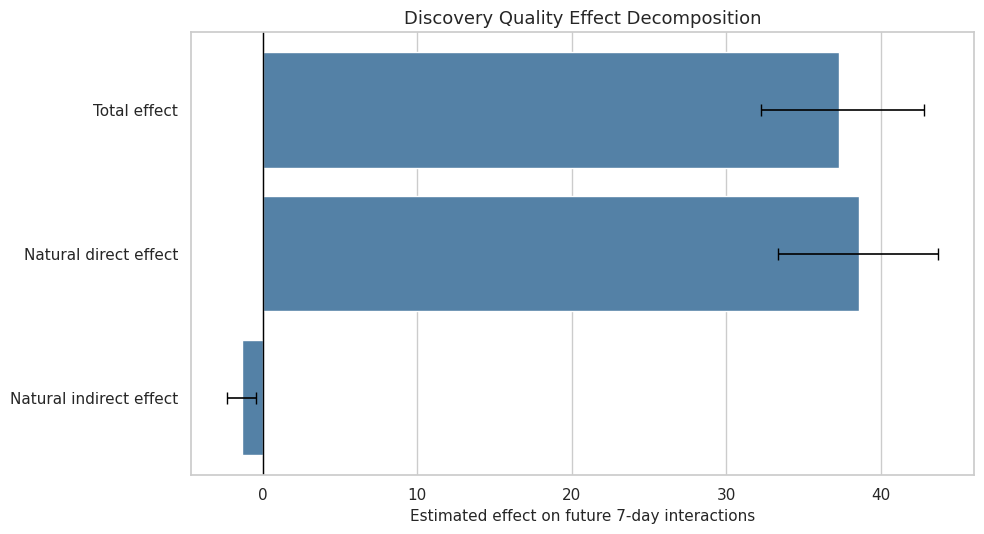

In [11]:
# Plot primary effect decomposition.
primary_plot = effect_summary.query(
    "outcome == @PRIMARY_OUTCOME and estimand in ['gcomp_total_effect', 'natural_direct_effect', 'natural_indirect_effect']"
).copy()
primary_plot["label"] = primary_plot["estimand"].map(
    {
        "gcomp_total_effect": "Total effect",
        "natural_direct_effect": "Natural direct effect",
        "natural_indirect_effect": "Natural indirect effect",
    }
)
primary_plot["lower_error"] = primary_plot["estimate"] - primary_plot["ci_95_lower"]
primary_plot["upper_error"] = primary_plot["ci_95_upper"] - primary_plot["estimate"]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=primary_plot, x="estimate", y="label", color="steelblue", ax=ax)
for row_index, row in primary_plot.reset_index(drop=True).iterrows():
    ax.errorbar(
        x=row["estimate"],
        y=row_index,
        xerr=[[row["lower_error"]], [row["upper_error"]]],
        fmt="none",
        color="black",
        capsize=4,
        linewidth=1.2,
    )
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Discovery Quality Effect Decomposition")
ax.set_xlabel("Estimated effect on future 7-day interactions")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


This plot answers the headline mediation question visually: how much of the future-interaction effect appears direct versus routed through same-day satisfaction depth. The implication for mediation is that the direct and indirect components must be interpreted as a connected pathway decomposition.


### Compare Effects Across Outcomes

This cell compares the same decomposition across all three future outcomes. The alternate outcomes help check whether the result is specific to interaction count or whether it also appears for active days and play hours.

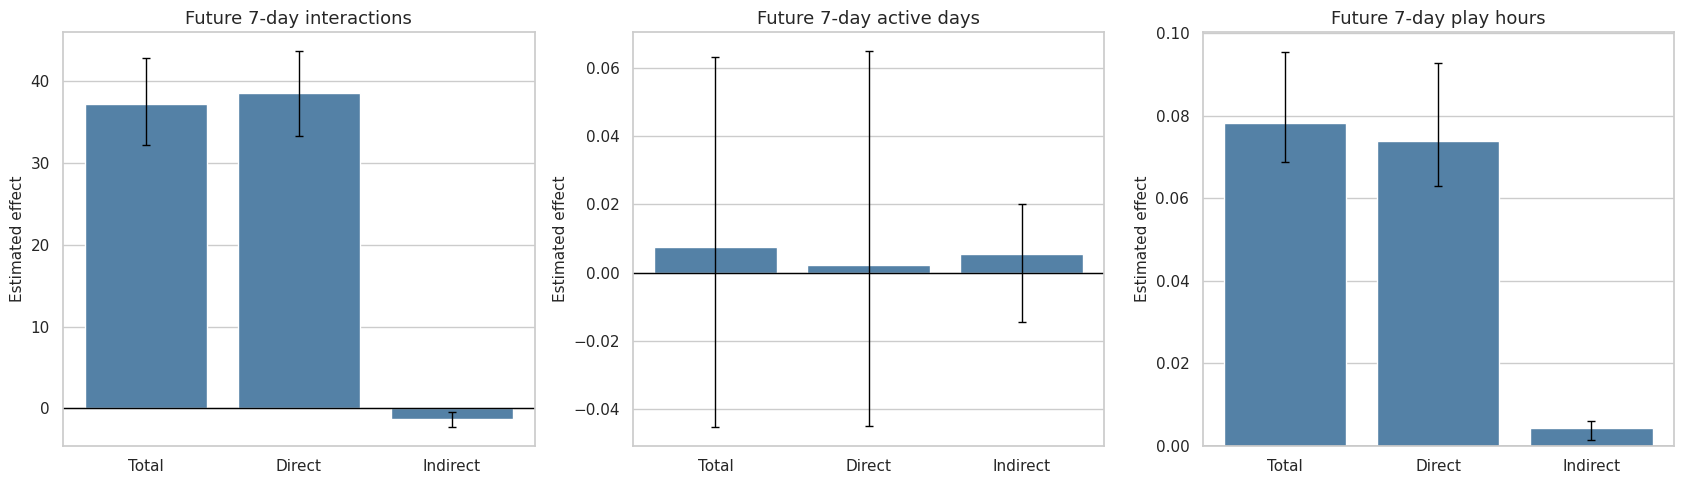

,outcome_label,estimand_label,estimate,ci_95_lower,ci_95_upper,relative_effect
2,Future 7-day interactions,Total,37.2781,32.2444,42.8135,0.1152
3,Future 7-day interactions,Direct,38.5858,33.3634,43.7154,0.1192
4,Future 7-day interactions,Indirect,-1.3077,-2.3047,-0.4290,-0.0036
9,Future 7-day active days,Total,0.0074,-0.0452,0.0631,0.0011
10,Future 7-day active days,Direct,0.0021,-0.0449,0.0648,0.0003
11,Future 7-day active days,Indirect,0.0053,-0.0145,0.0201,0.0008
16,Future 7-day play hours,Total,0.0784,0.0689,0.0954,0.1000
17,Future 7-day play hours,Direct,0.0739,0.0630,0.0927,0.0943
18,Future 7-day play hours,Indirect,0.0044,0.0014,0.0060,0.0051


In [12]:
# Compare effects across outcomes.
outcome_plot = effect_summary.query(
    "estimand in ['gcomp_total_effect', 'natural_direct_effect', 'natural_indirect_effect']"
).copy()
outcome_plot["estimand_label"] = outcome_plot["estimand"].map(
    {
        "gcomp_total_effect": "Total",
        "natural_direct_effect": "Direct",
        "natural_indirect_effect": "Indirect",
    }
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)
for ax, outcome in zip(axes, OUTCOME_COLUMNS):
    current = outcome_plot.query("outcome == @outcome").copy()
    sns.barplot(data=current, x="estimand_label", y="estimate", color="steelblue", ax=ax)
    for row_index, row in current.reset_index(drop=True).iterrows():
        lower = row["estimate"] - row["ci_95_lower"]
        upper = row["ci_95_upper"] - row["estimate"]
        ax.errorbar(
            x=row_index,
            y=row["estimate"],
            yerr=[[lower], [upper]],
            fmt="none",
            color="black",
            capsize=3,
            linewidth=1,
        )
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(OUTCOME_LABELS[outcome])
    ax.set_xlabel("")
    ax.set_ylabel("Estimated effect")

plt.tight_layout()
plt.show()

display(
    outcome_plot[
        ["outcome_label", "estimand_label", "estimate", "ci_95_lower", "ci_95_upper", "relative_effect"]
    ].round(4)
)


The outcome comparison is a robustness check on the practical story. Interaction-count effects can be large while active-day effects are small if most users are already active almost every day.

### Estimate Controlled Direct Effects

This cell summarizes controlled direct effects at low, median, and high satisfaction-depth levels. Unlike the natural direct effect, a controlled direct effect fixes the mediator to a chosen value for everyone. That makes it useful for asking whether discovery exposure has a different direct effect under weak versus strong satisfaction.

In [13]:
controlled_ci = (
    bootstrap_effects.query("estimand == 'gcomp_total_effect'")
    .head(0)
    .copy()
)

# Controlled direct effects are lighter-weight sensitivity summaries, so the notebook reports point estimates.
controlled_direct_effects = weighted_cde.copy()
controlled_direct_effects["mediator_level_label"] = controlled_direct_effects["mediator_level"].map(
    {
        "low_satisfaction_q25": "Low satisfaction (q25)",
        "median_satisfaction_q50": "Median satisfaction (q50)",
        "high_satisfaction_q75": "High satisfaction (q75)",
    }
)

display(controlled_direct_effects.round(4))


,outcome,outcome_label,mediator_level,mediator_value,controlled_direct_effect,uses_weights,mediator_level_label
0,Y_future_interactions,Future 7-day interactions,low_satisfaction_q25,0.5475,39.4525,True,Low satisfaction (q25)
1,Y_future_interactions,Future 7-day interactions,median_satisfaction_q50,0.6174,38.4273,True,Median satisfaction (q50)
2,Y_future_interactions,Future 7-day interactions,high_satisfaction_q75,0.6856,37.4271,True,High satisfaction (q75)
3,Y_future_active_days,Future 7-day active days,low_satisfaction_q25,0.5475,0.0206,True,Low satisfaction (q25)
4,Y_future_active_days,Future 7-day active days,median_satisfaction_q50,0.6174,-0.0013,True,Median satisfaction (q50)
5,Y_future_active_days,Future 7-day active days,high_satisfaction_q75,0.6856,-0.0227,True,High satisfaction (q75)
6,Y_future_play_hours,Future 7-day play hours,low_satisfaction_q25,0.5475,0.0690,True,Low satisfaction (q25)
7,Y_future_play_hours,Future 7-day play hours,median_satisfaction_q50,0.6174,0.0748,True,Median satisfaction (q50)
8,Y_future_play_hours,Future 7-day play hours,high_satisfaction_q75,0.6856,0.0805,True,High satisfaction (q75)


The controlled direct effects show whether the direct discovery effect changes as the satisfaction level is fixed higher or lower. If the direct effect is similar across levels, the treatment-mediator interaction has limited influence on the main result.

#### 14. Plot Controlled Direct Effects

This cell visualizes the controlled direct effects. The primary outcome is shown as a line across satisfaction levels, which makes it easier to see whether the direct exposure effect depends strongly on mediator level.

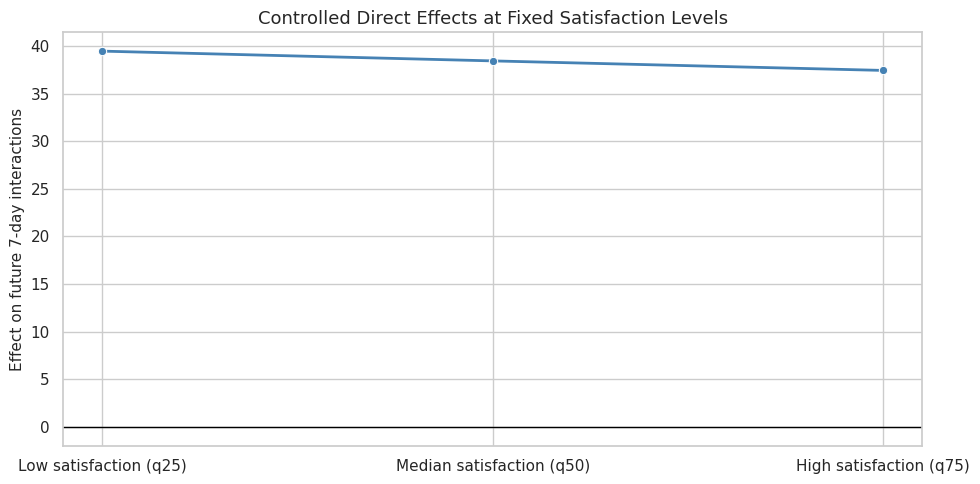

In [14]:
primary_cde = controlled_direct_effects.query("outcome == @PRIMARY_OUTCOME").copy()
mediator_level_order = ["Low satisfaction (q25)", "Median satisfaction (q50)", "High satisfaction (q75)"]
primary_cde["mediator_level_label"] = pd.Categorical(
    primary_cde["mediator_level_label"], categories=mediator_level_order, ordered=True
)
primary_cde = primary_cde.sort_values("mediator_level_label")

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=primary_cde,
    x="mediator_level_label",
    y="controlled_direct_effect",
    marker="o",
    linewidth=2,
    color="steelblue",
    ax=ax,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Controlled Direct Effects at Fixed Satisfaction Levels")
ax.set_xlabel("")
ax.set_ylabel("Effect on future 7-day interactions")
plt.tight_layout()
plt.show()


This plot complements the natural direct effect. Natural effects use predicted mediator distributions under treatment states; controlled effects use fixed mediator values that are easier to explain to a broad audience.

#### 15. Inspect Bootstrap Distributions

This cell plots bootstrap distributions for the primary total, direct, and indirect effects. A distribution centered far from zero supports a more stable result; a distribution that crosses zero heavily signals uncertainty.

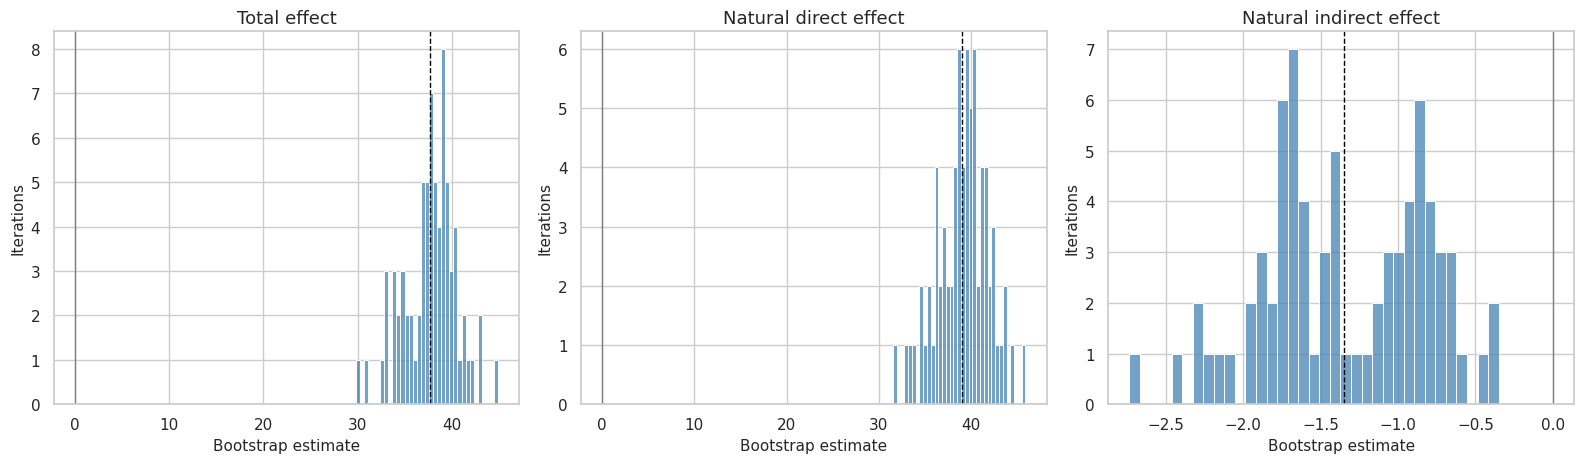

In [15]:
bootstrap_primary = bootstrap_effects.query(
    "outcome == @PRIMARY_OUTCOME and estimand in ['gcomp_total_effect', 'natural_direct_effect', 'natural_indirect_effect']"
).copy()
bootstrap_primary["estimand_label"] = bootstrap_primary["estimand"].map(
    {
        "gcomp_total_effect": "Total effect",
        "natural_direct_effect": "Natural direct effect",
        "natural_indirect_effect": "Natural indirect effect",
    }
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=False)
for ax, label in zip(axes, ["Total effect", "Natural direct effect", "Natural indirect effect"]):
    current = bootstrap_primary.query("estimand_label == @label")
    sns.histplot(data=current, x="estimate", bins=35, color="steelblue", edgecolor="white", ax=ax)
    ax.axvline(current["estimate"].mean(), color="black", linestyle="--", linewidth=1)
    ax.axvline(0, color="gray", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("Bootstrap estimate")
    ax.set_ylabel("Iterations")

plt.tight_layout()
plt.show()


The bootstrap distributions are useful for diagnosing whether the intervals are driven by a few unusual resamples or by broad uncertainty across user clusters. The implication for mediation is that the direct and indirect components must be interpreted as a connected pathway decomposition.


#### 16. Create a Plain-Language Results Table

This cell creates a compact results table with the most important primary-outcome rows and readable labels.

In [16]:
# Create a plain-language results table.
plain_language_rows = effect_summary.query(
    "outcome == @PRIMARY_OUTCOME and estimand in ['gcomp_total_effect', 'natural_direct_effect', 'natural_indirect_effect', 'mediator_shift_M1_minus_M0']"
).copy()
plain_language_rows["result_label"] = plain_language_rows["estimand"].map(
    {
        "gcomp_total_effect": "Total effect of high discovery exposure",
        "natural_direct_effect": "Direct effect not routed through satisfaction depth",
        "natural_indirect_effect": "Indirect effect routed through satisfaction depth",
        "mediator_shift_M1_minus_M0": "Estimated shift in satisfaction depth",
    }
)
plain_language_results = plain_language_rows[
    [
        "result_label",
        "estimate",
        "ci_95_lower",
        "ci_95_upper",
        "relative_effect",
        "proportion_mediated",
    ]
].copy()

# The mediator shift is on the mediator scale, so its relative effect and proportion mediated are not directly comparable.
plain_language_results.loc[
    plain_language_results["result_label"].eq("Estimated shift in satisfaction depth"),
    ["relative_effect", "proportion_mediated"],
] = np.nan

display(plain_language_results.round(4))


,result_label,estimate,ci_95_lower,ci_95_upper,relative_effect,proportion_mediated
2,Total effect of high discovery exposure,37.2781,32.2444,42.8135,0.1152,-0.0351
3,Direct effect not routed through satisfaction depth,38.5858,33.3634,43.7154,0.1192,-0.0351
4,Indirect effect routed through satisfaction depth,-1.3077,-2.3047,-0.4290,-0.0036,-0.0351
6,Estimated shift in satisfaction depth,0.0231,0.0185,0.0279,NaN,NaN


This table is the one to use when explaining the result to a non-technical reader. The full tables remain saved for reproducibility, but this version keeps the core story visible.

In [ ]:
#| include: false
# Save effect tables and figures.
all_effect_estimates = pd.concat(
    [
        weighted_effects.assign(estimator_variant="weighted_regression"),
        unweighted_effects.assign(estimator_variant="unweighted_regression"),
    ],
    ignore_index=True,
)
all_model_diagnostics = pd.concat(
    [
        weighted_model_diagnostics.assign(estimator_variant="weighted_regression"),
        unweighted_model_diagnostics.assign(estimator_variant="unweighted_regression"),
    ],
    ignore_index=True,
)

all_effect_estimates.to_csv(EFFECT_ESTIMATES_OUTPUT, index=False)
bootstrap_effects.to_csv(BOOTSTRAP_EFFECTS_OUTPUT, index=False)
effect_summary.to_csv(EFFECT_SUMMARY_OUTPUT, index=False)
controlled_direct_effects.to_csv(CONTROLLED_DIRECT_OUTPUT, index=False)
all_model_diagnostics.to_csv(MODEL_DIAGNOSTICS_OUTPUT, index=False)


### Takeaways and Next Step

This notebook estimated the discovery-quality mediation effects using transparent g-computation:

- The total effect compares high-discovery and lower-discovery user-days after observed adjustment.
- The natural direct effect captures the pathway that bypasses same-day satisfaction depth.
- The natural indirect effect captures the pathway through predicted satisfaction-depth changes.
- User-level bootstrap intervals quantify uncertainty while respecting repeated days per user.
- Alternate outcomes check whether the story is specific to interaction volume or also appears in active days and play time.

The next notebook should focus on robustness and sensitivity: alternative mediator definitions, alternative treatment thresholds, and sensitivity to unobserved mediator-outcome confounding.